# Análisis de Dependencias - SBOM Analyzer

Consolidación y análisis cuantitativo de SBOMs generados con Syft para 16 repositorios activos de PrefectHQ.

In [38]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print("✓ Librerías cargadas correctamente")

✓ Librerías cargadas correctamente


In [39]:
# Configurar ruta a los resultados
results_path = Path("../results")

# Listar todos los archivos SBOM (los que terminan en _sbom.json y no están vacíos)
sbom_files = sorted([f for f in results_path.glob("*_sbom.json") if f.stat().st_size > 0])

print(f"✓ Se encontraron {len(sbom_files)} archivos SBOM válidos")
print("\nPrimeros 5 archivos:")
for f in sbom_files[:5]:
    print(f"  - {f.name} ({f.stat().st_size / 1024:.1f} KB)")

✓ Se encontraron 17 archivos SBOM válidos

Primeros 5 archivos:
  - actions-updatecli-apply_sbom.json (14.5 KB)
  - colin_sbom.json (527.3 KB)
  - dev-log_sbom.json (11.7 KB)
  - fastmcp_sbom.json (773.9 KB)
  - marvin_sbom.json (1102.4 KB)


Analizamos el primer SBOM para entender su estrcutura

In [40]:
ejemplo = sbom_files[0]
print(f"Analizando: {ejemplo.name}\n")

with open(ejemplo, 'r') as f:
    data = json.load(f)

print("Claves principales del JSON:")
for key in data.keys():
    print(f"  - {key}")

if 'bomFormat' in data:
    print(f"\nFormato: {data['bomFormat']}")
    print(f"Versión: {data.get('specVersion', 'N/A')}")

Analizando: actions-updatecli-apply_sbom.json

Claves principales del JSON:
  - artifacts
  - artifactRelationships
  - files
  - source
  - distro
  - descriptor
  - schema


Exploramos la estrcutura de los artifacts

In [41]:
# Explorar la estructura de los artifacts (componentes)
artifacts = data.get('artifacts', [])

print(f"Total de componentes en {ejemplo.name}: {len(artifacts)}")

# Ver la estructura del primer componente
if artifacts:
    print("\nEstructura del primer componente:")
    primer_comp = artifacts[0]
    for key, value in primer_comp.items():
        if isinstance(value, (str, int, float, bool)) or value is None:
            print(f"  - {key}: {value}")
        elif isinstance(value, list):
            print(f"  - {key}: [lista con {len(value)} elementos]")
        elif isinstance(value, dict):
            print(f"  - {key}: {{diccionario}}")
    
    print("\nPrimer componente completo:")
    print(json.dumps(primer_comp, indent=2)[:1000] + "...")

Total de componentes en actions-updatecli-apply_sbom.json: 6

Estructura del primer componente:
  - id: 89fc164eb66dd39a
  - name: 8398a7/action-slack
  - version: v3
  - type: github-action
  - foundBy: github-actions-usage-cataloger
  - locations: [lista con 1 elementos]
  - licenses: [lista con 0 elementos]
  - language: 
  - cpes: [lista con 6 elementos]
  - purl: pkg:github/8398a7/action-slack@v3
  - metadataType: github-actions-use-statement
  - metadata: {diccionario}

Primer componente completo:
{
  "id": "89fc164eb66dd39a",
  "name": "8398a7/action-slack",
  "version": "v3",
  "type": "github-action",
  "foundBy": "github-actions-usage-cataloger",
  "locations": [
    {
      "path": "/.github/workflows/notify-on-failure.yaml",
      "accessPath": "/.github/workflows/notify-on-failure.yaml",
      "annotations": {
        "evidence": "primary"
      }
    }
  ],
  "licenses": [],
  "language": "",
  "cpes": [
    {
      "cpe": "cpe:2.3:a:8398a7\\/action-slack:8398a7\\/action-

Definimos la funcion que utilizaremos para procesar los SBOMs

In [ ]:
def parse_sbom(file_path, repo_name):
    """Extrae los componentes de un SBOM y los devuelve como lista de diccionarios"""
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    artifacts = data.get('artifacts', [])
    components = []
    
    for artifact in artifacts:
        # Extraer licencias (puede ser lista vacía o lista de objetos con 'name')
        license_names = []
        for lic in artifact.get('licenses', []):
            if isinstance(lic, dict) and 'name' in lic:
                license_names.append(lic['name'])
            elif isinstance(lic, str):
                license_names.append(lic)
        
        component = {
            'repo': repo_name,
            'name': artifact.get('name', ''),
            'version': artifact.get('version', ''),
            'type': artifact.get('type', ''),
            'purl': artifact.get('purl', ''),
            'language': artifact.get('language', ''),
            'licenses': ', '.join(license_names) if license_names else None,
            'cpe_count': len(artifact.get('cpes', []))
        }
        components.append(component)
    
    return components


Procesamos los SBOMs con la funcion antes definida y creamos el DataFrame que se utilizara para el analisis

In [ ]:

all_components = []

for sbom_file in sbom_files:
    repo_name = sbom_file.stem.replace('_sbom', '')
    print(f"Procesando {repo_name}...")
    
    components = parse_sbom(sbom_file, repo_name)
    all_components.extend(components)
    print(f"  → {len(components)} componentes")

df_components = pd.DataFrame(all_components)

print(f"\n✓ DataFrame creado con {len(df_components)} componentes")
print(f"  Columnas: {list(df_components.columns)}")

Procesando actions-updatecli-apply...
  → 6 componentes
Procesando colin...
  → 190 componentes
Procesando dev-log...
  → 6 componentes
Procesando fastmcp...
  → 303 componentes
Procesando marvin...
  → 414 componentes
Procesando prefab...
  → 518 componentes
Procesando prefect-cloud...
  → 69 componentes
Procesando prefect-design...
  → 253 componentes
Procesando prefect-fastmcp-demos...
  → 93 componentes
Procesando prefect-helm...
  → 26 componentes
Procesando prefect-mcp-server...
  → 256 componentes
Procesando prefect-operator...
  → 99 componentes
Procesando prefect...
  → 1181 componentes
Procesando prometheus-prefect-exporter...
  → 12 componentes
Procesando qa-wolf-flows...
  → 0 componentes
Procesando terraform-prefect-bucket-sensor...
  → 7 componentes
Procesando terraform-provider-prefect...
  → 107 componentes

✓ DataFrame creado con 3540 componentes
  Columnas: ['repo', 'name', 'version', 'type', 'purl', 'language', 'licenses', 'cpe_count']


Imprimir las 10 primeras filas del DataFrame para verificar su creacion

In [43]:
# Primeras filas del DataFrame
print("Primeras 10 filas del DataFrame:")
df_components.head(10)


Primeras 10 filas del DataFrame:


,repo,name,version,type,purl,language,licenses,cpe_count
0,actions-updatecli-apply,8398a7/action-slack,v3,github-action,pkg:github/8398a7/action-slack@v3,,None,6
1,actions-updatecli-apply,actions/checkout,v6,github-action,pkg:github/actions/checkout@v6,,None,1
2,actions-updatecli-apply,actions/checkout,v6,github-action,pkg:github/actions/checkout@v6,,None,1
3,actions-updatecli-apply,jdx/mise-action,v4,github-action,pkg:github/jdx/mise-action@v4,,None,6
4,actions-updatecli-apply,prefecthq/actions-mise-upgrade,main,github-action,pkg:github/prefecthq/actions-mise-upgrade@main,,None,10
5,actions-updatecli-apply,prefecthq/actions-updatecli-apply,${{ github.head_ref }},github-action,pkg:github/prefecthq/actions-updatecli-apply@%...,,None,10
6,colin,actions/checkout,v4,github-action,pkg:github/actions/checkout@v4,,None,1
7,colin,actions/checkout,v4,github-action,pkg:github/actions/checkout@v4,,None,1
8,colin,actions/checkout,v4,github-action,pkg:github/actions/checkout@v4,,None,1
9,colin,actions/checkout,v4,github-action,pkg:github/actions/checkout@v4,,None,1


Generamos las estadisticas basicas en base al DataFrame creado anteriomente

In [ ]:
print("=== ESTADÍSTICAS BÁSICAS ===\n")
print(f"Total de componentes: {len(df_components)}")
print(f"Repositorios analizados: {df_components['repo'].nunique()}")
print(f"Tipos de componentes únicos: {df_components['type'].nunique()}")
print(f"Componentes con licencia: {df_components['licenses'].notna().sum()}")
print(f"Componentes sin licencia: {df_components['licenses'].isna().sum()}")

=== ESTADÍSTICAS BÁSICAS ===

Total de componentes: 3540
Repositorios analizados: 16
Tipos de componentes únicos: 5
Componentes con licencia: 0
Componentes sin licencia: 3540


Analizamos la cantidad de componentes por tipo

=== DISTRIBUCIÓN POR TIPO DE COMPONENTE ===

type
python                    1670
npm                       1330
github-action              378
go-module                  149
github-action-workflow      13
Name: count, dtype: int64


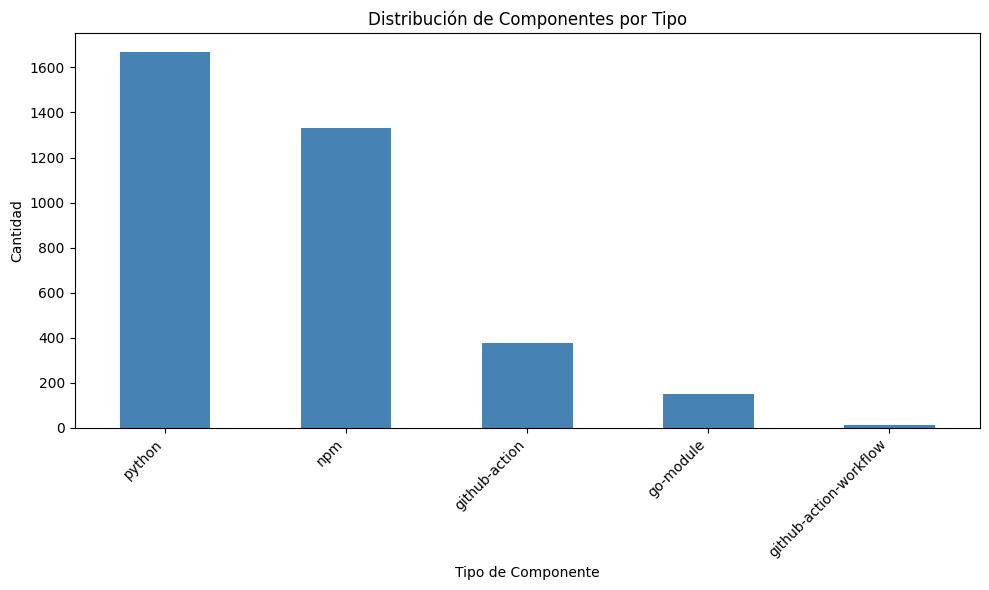

In [ ]:
print("=== DISTRIBUCIÓN POR TIPO DE COMPONENTE ===\n")
type_counts = df_components['type'].value_counts()
print(type_counts)

plt.figure(figsize=(10, 6))
type_counts.plot(kind='bar', color='steelblue')
plt.title('Distribución de Componentes por Tipo')
plt.xlabel('Tipo de Componente')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Analizamos la cantidad de componentes por repositorio


=== COMPONENTES POR REPOSITORIO ===

repo
prefect                            1181
prefab                              518
marvin                              414
fastmcp                             303
prefect-mcp-server                  256
prefect-design                      253
colin                               190
terraform-provider-prefect          107
prefect-operator                     99
prefect-fastmcp-demos                93
prefect-cloud                        69
prefect-helm                         26
prometheus-prefect-exporter          12
terraform-prefect-bucket-sensor       7
actions-updatecli-apply               6
dev-log                               6
Name: count, dtype: int64


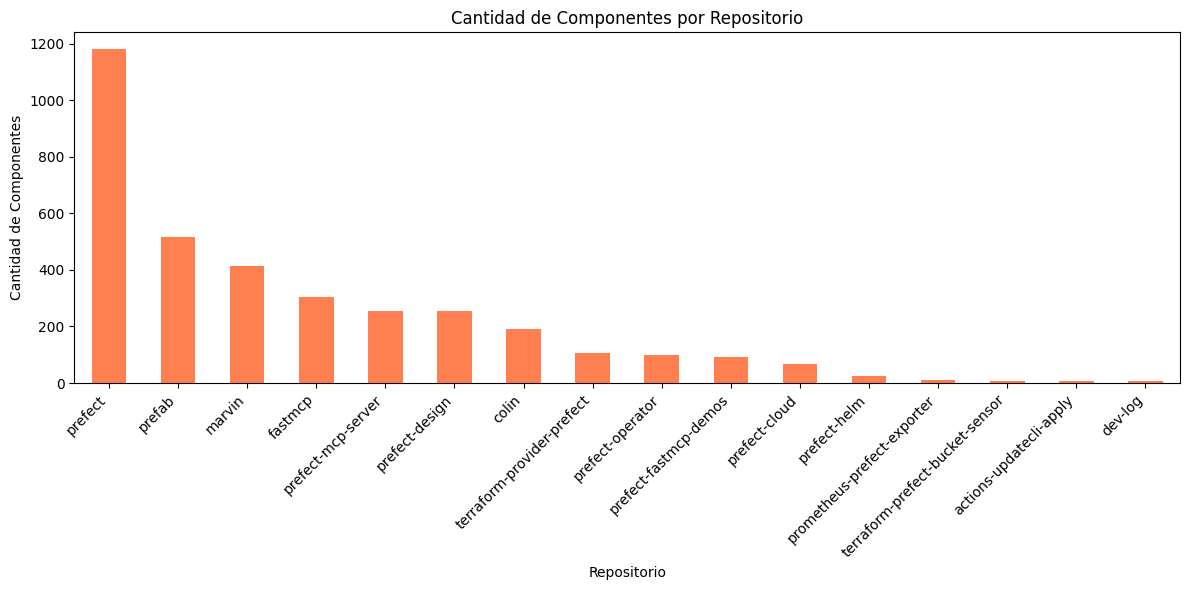

In [46]:
# Componentes por repositorio
print("\n=== COMPONENTES POR REPOSITORIO ===\n")
repo_counts = df_components['repo'].value_counts()
print(repo_counts)

plt.figure(figsize=(12, 6))
repo_counts.plot(kind='bar', color='coral')
plt.title('Cantidad de Componentes por Repositorio')
plt.xlabel('Repositorio')
plt.ylabel('Cantidad de Componentes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Generamos metricas cuantitativas para el informe

In [ ]:
print("=== MÉTRICAS CUANTITATIVAS DE DEPENDENCIAS ===\n")

total_componentes = len(df_components)
total_repos = df_components['repo'].nunique()

print(f"📦 TOTALES:")
print(f"  • Repositorios analizados: {total_repos}")
print(f"  • Componentes totales: {total_componentes}")
print(f"  • Promedio de componentes por repo: {total_componentes/total_repos:.1f}")

print(f"\n🌐 DISTRIBUCIÓN POR ECOSISTEMA:")
ecosystem_counts = df_components['type'].value_counts()
for eco, count in ecosystem_counts.items():
    pct = (count / total_componentes) * 100
    print(f"  • {eco}: {count} ({pct:.1f}%)")

print(f"\n🔝 TOP 10 COMPONENTES MÁS FRECUENTES:")
top_components = df_components['name'].value_counts().head(10)
for name, count in top_components.items():
    print(f"  • {name}: {count} repositorios")

componentes_unicos = df_components['name'].nunique()
print(f"\n🔄 DEDUPLICACIÓN:")
print(f"  • Componentes únicos: {componentes_unicos}")
print(f"  • Componentes totales: {total_componentes}")
print(f"  • Tasa de reutilización: {total_componentes/componentes_unicos:.2f}x")

=== MÉTRICAS CUANTITATIVAS DE DEPENDENCIAS ===

📦 TOTALES:
  • Repositorios analizados: 16
  • Componentes totales: 3540
  • Promedio de componentes por repo: 221.2

🌐 DISTRIBUCIÓN POR ECOSISTEMA:
  • python: 1670 (47.2%)
  • npm: 1330 (37.6%)
  • github-action: 378 (10.7%)
  • go-module: 149 (4.2%)
  • github-action-workflow: 13 (0.4%)

🔝 TOP 10 COMPONENTES MÁS FRECUENTES:
  • actions/checkout: 116 repositorios
  • astral-sh/setup-uv: 43 repositorios
  • actions/setup-node: 14 repositorios
  • actions/create-github-app-token: 13 repositorios
  • docker/setup-buildx-action: 13 repositorios
  • ipython: 12 repositorios
  • jdx/mise-action: 11 repositorios
  • docker/build-push-action: 11 repositorios
  • annotated-types: 10 repositorios
  • anyio: 10 repositorios

🔄 DEDUPLICACIÓN:
  • Componentes únicos: 1516
  • Componentes totales: 3540
  • Tasa de reutilización: 2.34x


Analizamos los 10 repositorios con mayor cantidad de componentes

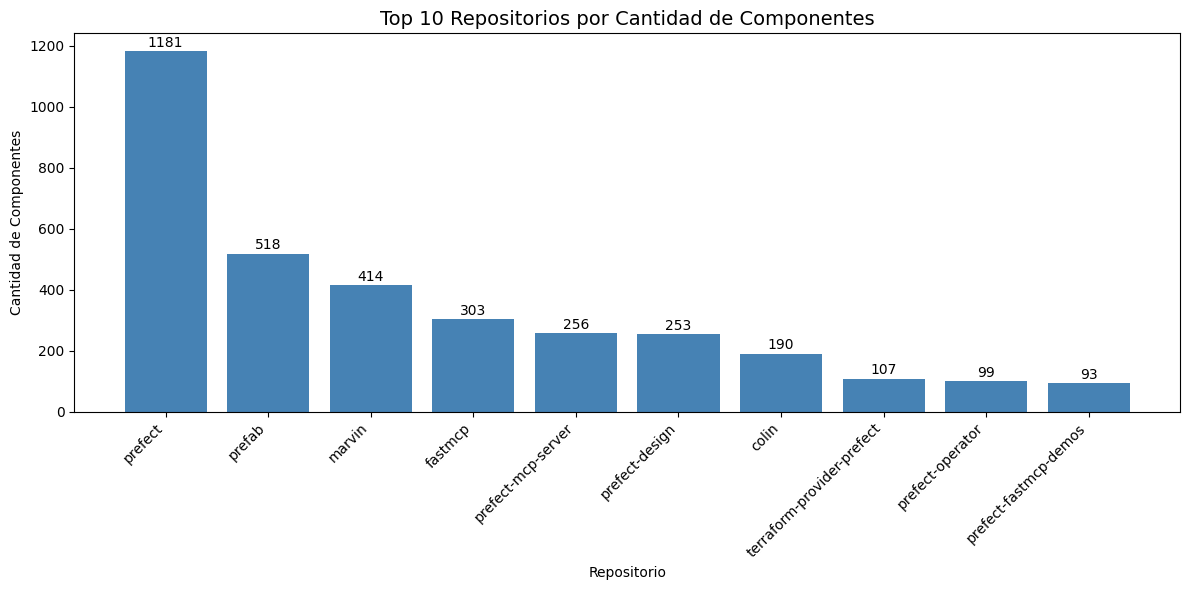

In [ ]:
top_repos = df_components['repo'].value_counts().head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(top_repos.index, top_repos.values, color='steelblue')
plt.title('Top 10 Repositorios por Cantidad de Componentes', fontsize=14)
plt.xlabel('Repositorio')
plt.ylabel('Cantidad de Componentes')
plt.xticks(rotation=45, ha='right')

for bar, value in zip(bars, top_repos.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()

Analizamos la distribuacion de componentes por ecosistema

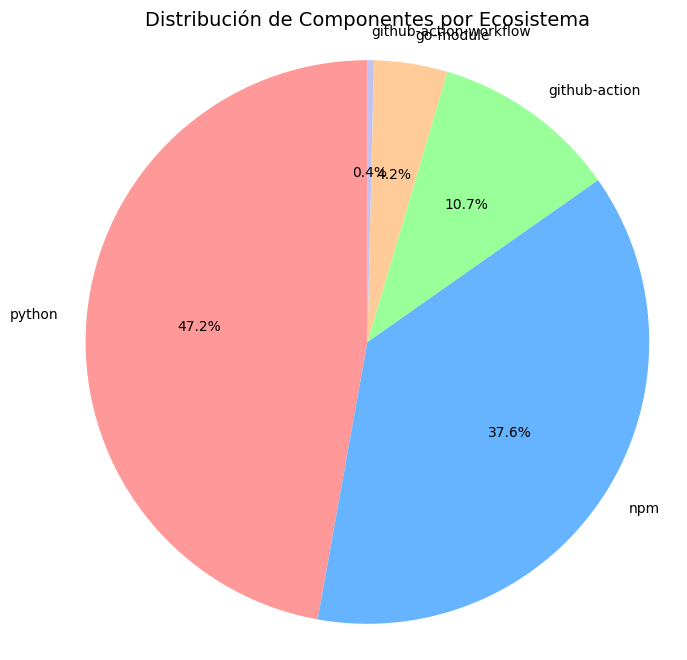

In [ ]:
plt.figure(figsize=(8, 8))
ecosystem_counts = df_components['type'].value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']
plt.pie(ecosystem_counts.values, labels=ecosystem_counts.index, 
        autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Distribución de Componentes por Ecosistema', fontsize=14)
plt.axis('equal')
plt.show()

Componentes con identificador (CPE)

In [50]:
# Componentes que tienen CPE (identificadores de vulnerabilidad)
con_cpe = df_components[df_components['cpe_count'] > 0]
sin_cpe = df_components[df_components['cpe_count'] == 0]

print(f"Componentes CON CPE: {len(con_cpe)} ({len(con_cpe)/len(df_components)*100:.1f}%)")
print(f"Componentes SIN CPE: {len(sin_cpe)} ({len(sin_cpe)/len(df_components)*100:.1f}%)")

# Por ecosistema
print("\nComponentes con CPE por ecosistema:")
cpe_by_type = con_cpe.groupby('type').size().sort_values(ascending=False)
for eco, count in cpe_by_type.items():
    total_eco = ecosystem_counts[eco]
    pct = (count / total_eco) * 100
    print(f"  • {eco}: {count}/{total_eco} ({pct:.1f}%)")

Componentes CON CPE: 3524 (99.5%)
Componentes SIN CPE: 16 (0.5%)

Componentes con CPE por ecosistema:
  • python: 1670/1670 (100.0%)
  • npm: 1330/1330 (100.0%)
  • github-action: 378/378 (100.0%)
  • go-module: 133/149 (89.3%)
  • github-action-workflow: 13/13 (100.0%)


Exportamos los componentes a un DataFrame

In [ ]:
output_path = Path("../results")
output_file = output_path / "componentes_consolidados.csv"
df_components.to_csv(output_file, index=False)

print(f"✓ DataFrame exportado exitosamente")
print(f"  Archivo: {output_file}")
print(f"  Registros: {len(df_components)}")

✓ DataFrame exportado exitosamente
  Archivo: ../results/componentes_consolidados.csv
  Registros: 3540


Exploramos la estructura de las vulnerabilidades analizando el primer archivo de vulnerabilidad


In [ ]:
# Definimos la ruta a los resultados de vulnerabilidades
vuln_files = list(results_path.glob("*_vulns.json"))

if not vuln_files:
    print("No se encontraron archivos de vulnerabilidades '_vulns.json' en la carpeta '../results'.")
else:
    # Tomamos automáticamente el PRIMER archivo de la lista
    ruta_archivo = vuln_files[0]
    print(f"Archivo detectado: {ruta_archivo.name}")
    
    try:
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        matches = data.get('matches', [])
        print(f"- Total de vulnerabilidades (matches) encontradas: {len(matches)}")

        if len(matches) > 0:
            print("-  Estructura del primer hallazgo:")
            primer_match = matches[0]
            for key, value in primer_match.items():
                if isinstance(value, (str, int, float, bool)) or value is None:
                    print(f"  - {key}: {value}")
                elif isinstance(value, list):
                    print(f"  - {key}: [lista con {len(value)} elementos]")
                elif isinstance(value, dict):
                    print(f"  - {key}: {{diccionario con {len(value.keys())} llaves}}")
            
            print("- Primer hallazgo completo:")
            print(json.dumps(primer_match, indent=2)[:1000] + "\n...")
        else:
            print("No se encontraron vulnerabilidades en el archivo.")
            
    except json.JSONDecodeError:
        print(f"Error al leer el archivo {ruta_archivo.name}")

Archivo detectado: prefect-fastmcp-demos_vulns.json
- Total de vulnerabilidades (matches) encontradas: 22
-  Estructura del primer hallazgo:
  - vulnerability: {diccionario con 12 llaves}
  - relatedVulnerabilities: [lista con 1 elementos]
  - matchDetails: [lista con 1 elementos]
  - artifact: {diccionario con 10 llaves}
- Primer hallazgo completo:
{
  "vulnerability": {
    "id": "GHSA-vv7q-7jx5-f767",
    "dataSource": "https://github.com/advisories/GHSA-vv7q-7jx5-f767",
    "namespace": "github:language:python",
    "severity": "Critical",
    "urls": [
      "https://github.com/PrefectHQ/fastmcp/security/advisories/GHSA-vv7q-7jx5-f767",
      "https://nvd.nist.gov/vuln/detail/CVE-2026-32871",
      "https://github.com/PrefectHQ/fastmcp/pull/3507",
      "https://github.com/PrefectHQ/fastmcp/commit/40bdfb6b1de0ce30609ee9ba5bb95ecd04a9fb71",
      "https://github.com/PrefectHQ/fastmcp/releases/tag/v3.2.0"
    ],
    "description": "FastMCP OpenAPI Provider has an SSRF & Path Travers

Definimos la funcion que usaremos para parsear las vulnerabilidades


In [ ]:
def parse_vulnerabilidades(file_path, repo_name):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        matches = data.get("matches", [])
        vulns_list = []
        
        for m in matches:
            # Separamos la info de la vulnerabilidad y la info del paquete infectado
            v = m.get("vulnerability", {})
            a = m.get("artifact", {})
            
            vulns_list.append({
                "repositorio": repo_name,
                "componente": a.get("name", "Desconocido"),
                "ecosistema": a.get("language", "No especificado"),
                "vulnerabilidad_id": v.get("id", "Sin ID"),
                "severidad": v.get("severity", "Desconocida")
            })
            
        return vulns_list
        
    except json.JSONDecodeError:
        print(f"Error al leer el archivo JSON: {file_path.name}")
        return []

Analizamos las vulnerabilidades usando la funcion antes definida

In [ ]:
all_vulnerabilities = []

for vuln_file in vuln_files:
    repo_name = vuln_file.stem.replace('_vulns', '')
    print(f"Procesando vulnerabilidades en {repo_name}...")
    vulns = parse_vulnerabilidades(vuln_file, repo_name)
    all_vulnerabilities.extend(vulns)
    print(f"- {len(vulns)} vulnerabilidades encontradas")

df_vulns = pd.DataFrame(all_vulnerabilities)

print(f"\n✓ DataFrame creado con {len(df_vulns)} vulnerabilidades totales")
print(f"  Columnas: {list(df_vulns.columns)}")

# Mostramos una muestra para verificar que todo salió bien
display(df_vulns.head())

Procesando vulnerabilidades en prefect-fastmcp-demos...
- 22 vulnerabilidades encontradas
Procesando vulnerabilidades en prefect-operator...
- 0 vulnerabilidades encontradas
Procesando vulnerabilidades en qa-wolf-flows...
- 0 vulnerabilidades encontradas
Procesando vulnerabilidades en actions-updatecli-apply...
- 0 vulnerabilidades encontradas
Procesando vulnerabilidades en dev-log...
- 0 vulnerabilidades encontradas
Procesando vulnerabilidades en prefab...
- 2 vulnerabilidades encontradas
Procesando vulnerabilidades en colin...
- 34 vulnerabilidades encontradas
Procesando vulnerabilidades en prometheus-prefect-exporter...
- 0 vulnerabilidades encontradas
Procesando vulnerabilidades en terraform-prefect-bucket-sensor...
- 0 vulnerabilidades encontradas
Procesando vulnerabilidades en terraform-provider-prefect...
- 0 vulnerabilidades encontradas
Procesando vulnerabilidades en marvin...
- 97 vulnerabilidades encontradas
Procesando vulnerabilidades en prefect-helm...
- 0 vulnerabilidades 

,repositorio,componente,ecosistema,vulnerabilidad_id,severidad
0,prefect-fastmcp-demos,fastmcp,python,GHSA-vv7q-7jx5-f767,Critical
1,prefect-fastmcp-demos,jaraco-context,python,GHSA-58pv-8j8x-9vj2,High
2,prefect-fastmcp-demos,authlib,python,GHSA-wvwj-cvrp-7pv5,Critical
3,prefect-fastmcp-demos,fastmcp,python,GHSA-rww4-4w9c-7733,High
4,prefect-fastmcp-demos,cryptography,python,GHSA-p423-j2cm-9vmq,Medium


Exportamos un DataFrame de Vulnerabilidades

In [55]:
# Exportar DataFrame de Vulnerabilidades
output_file_vulns = results_path / "vulnerabilidades_consolidadas.csv"
df_vulns.to_csv(output_file_vulns, index=False)

print(f"✓ Reporte de vulnerabilidades exportado a: {output_file_vulns}")


✓ Reporte de vulnerabilidades exportado a: ../results/vulnerabilidades_consolidadas.csv


Analizamos el nivel de las vulnerabilidades y su cantidad

Resumen por Severidad:
----------------------------------------
  • Critical  : 12    (5.8%)
  • High      : 69    (33.2%)
  • Medium    : 90    (43.3%)
  • Low       : 37    (17.8%)
----------------------------------------
  TOTAL     : 208 vulnerabilidades



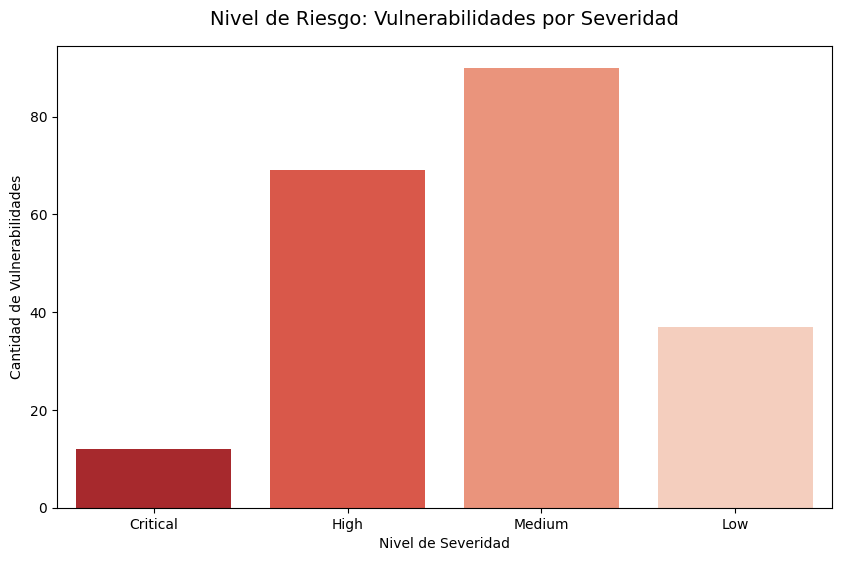

In [56]:
# 1. IMPRIMIR DATOS CRUDOS (Resumen Cuantitativo)
conteo_severidad = df_vulns['severidad'].value_counts()
total_vulns = len(df_vulns)

print("Resumen por Severidad:")
print("-" * 40)

# Definimos el orden lógico de las severidades
orden_severidad = ['Critical', 'High', 'Medium', 'Low', 'Negligible', 'Unknown']
orden_presente = [s for s in orden_severidad if s in df_vulns['severidad'].unique()]

# Iteramos sobre el orden lógico para imprimir ordenado
for severidad in orden_presente:
    cantidad = conteo_severidad.get(severidad, 0)
    porcentaje = (cantidad / total_vulns) * 100 if total_vulns > 0 else 0
    print(f"  • {severidad:<10}: {cantidad:<5} ({porcentaje:.1f}%)")

print("-" * 40)
print(f"  TOTAL     : {total_vulns} vulnerabilidades\n")


# 2. GENERAR EL GRÁFICO
plt.figure(figsize=(10, 6))

# Generar el gráfico de barras
sns.countplot(data=df_vulns, x='severidad', hue='severidad', order=orden_presente, palette='Reds_r', legend=False)

plt.title('Nivel de Riesgo: Vulnerabilidades por Severidad', fontsize=14, pad=15)
plt.xlabel('Nivel de Severidad')
plt.ylabel('Cantidad de Vulnerabilidades')

plt.show()

Analizamos la cantidad de vulnerabilidades por ecosistema (lenguaje) en el repositorio

📊 Resumen Cuantitativo por Ecosistema:
---------------------------------------------
  • python         : 181   (87.0%)
  • javascript     : 22    (10.6%)
  •                : 5     (2.4%)
---------------------------------------------
  TOTAL          : 208 vulnerabilidades



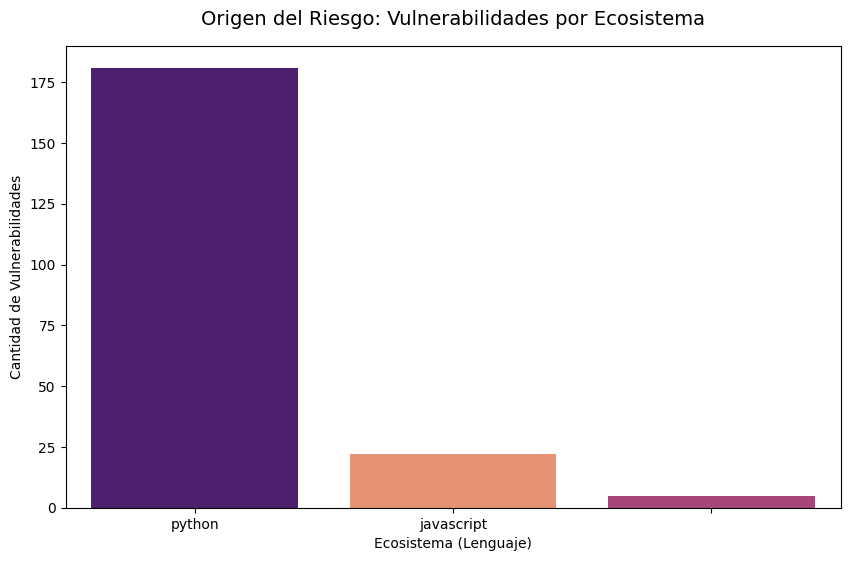

In [ ]:
conteo_eco = df_vulns['ecosistema'].value_counts()
total_vulns = len(df_vulns)

print("📊 Resumen Cuantitativo por Ecosistema:")
print("-" * 45)

# Ordenamos de mayor a menor cantidad de vulnerabilidades
orden_eco = conteo_eco.index

# Iteramos para imprimir los datos crudos y porcentajes
for eco in orden_eco:
    cantidad = conteo_eco[eco]
    porcentaje = (cantidad / total_vulns) * 100 if total_vulns > 0 else 0
    # Usamos :<15 para alinear bien los nombres largos de los ecosistemas
    print(f"  • {eco:<15}: {cantidad:<5} ({porcentaje:.1f}%)")

print("-" * 45)
print(f"  TOTAL          : {total_vulns} vulnerabilidades\n")

# 2. GENERAR EL GRÁFICO
plt.figure(figsize=(10, 6))

# Generar gráfico
sns.countplot(data=df_vulns, x='ecosistema', hue='ecosistema', order=orden_eco, palette='magma', legend=False)

plt.title('Origen del Riesgo: Vulnerabilidades por Ecosistema', fontsize=14, pad=15)
plt.xlabel('Ecosistema (Lenguaje)')
plt.ylabel('Cantidad de Vulnerabilidades')

plt.show()

Analizamos las vulnerabilidades por repositorios

📊 Resumen Cuantitativo: Todos los Repositorios Analizados:
-----------------------------------------------------------------
  • marvin                        : 97    (46.6%)
  • colin                         : 34    (16.3%)
  • prefect-fastmcp-demos         : 22    (10.6%)
  • prefect-mcp-server            : 16    (7.7%)
  • prefect-design                : 16    (7.7%)
  • prefect                       : 12    (5.8%)
  • fastmcp                       : 6     (2.9%)
  • prefect-cloud                 : 3     (1.4%)
  • prefab                        : 2     (1.0%)
-----------------------------------------------------------------
  TOTAL GENERAL                  : 208 vulnerabilidades

  💡 NOTA: El Top 5 del gráfico representa el 88.9% de todos los riesgos (185/208)



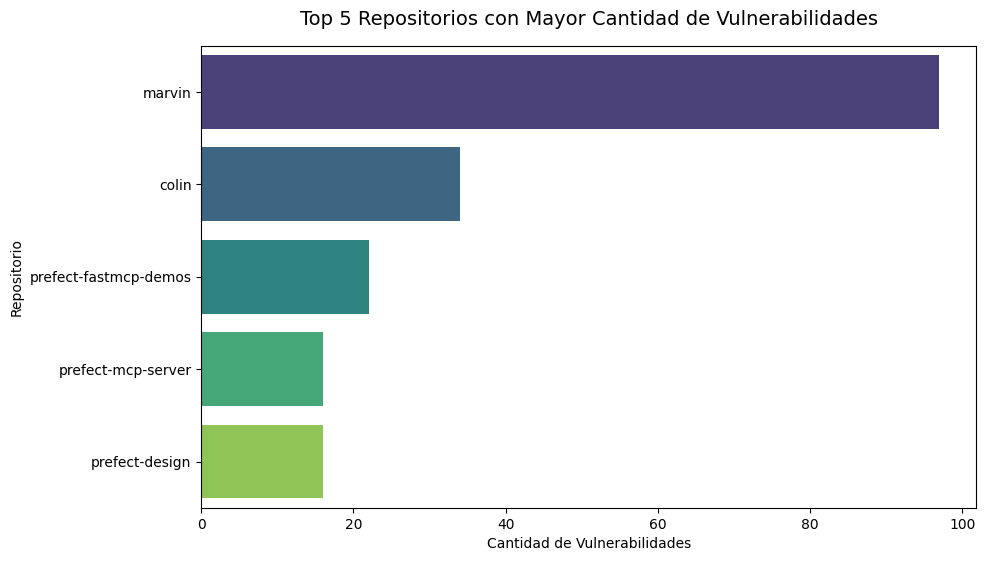

In [58]:
# 1. IMPRIMIR DATOS CRUDOS (Resumen Cuantitativo COMPLETO)
conteo_repos = df_vulns['repositorio'].value_counts()
total_vulns = len(df_vulns)

print("📊 Resumen Cuantitativo: Todos los Repositorios Analizados:")
print("-" * 65)

# Iteramos para imprimir TODOS los repositorios (sin límite)
for repo in conteo_repos.index:
    cantidad = conteo_repos[repo]
    porcentaje = (cantidad / total_vulns) * 100 if total_vulns > 0 else 0
    print(f"  • {repo:<30}: {cantidad:<5} ({porcentaje:.1f}%)")

print("-" * 65)
print(f"  TOTAL GENERAL                  : {total_vulns} vulnerabilidades\n")

# 2. GENERAR EL GRÁFICO (LIMITADO SOLO AL TOP 5)
top_repos = conteo_repos.head(5) # Aquí le ponemos el límite
suma_top5 = top_repos.sum()
pct_top5 = (suma_top5 / total_vulns) * 100 if total_vulns > 0 else 0

print(f"  💡 NOTA: El Top 5 del gráfico representa el {pct_top5:.1f}% de todos los riesgos ({suma_top5}/{total_vulns})\n")

plt.figure(figsize=(10, 6))

# Gráfico de barras horizontales usando solo 'top_repos'
sns.barplot(x=top_repos.values, y=top_repos.index, hue=top_repos.index, palette='viridis', legend=False)

plt.title('Top 5 Repositorios con Mayor Cantidad de Vulnerabilidades', fontsize=14, pad=15)
plt.xlabel('Cantidad de Vulnerabilidades')
plt.ylabel('Repositorio')

plt.show()

## Conclusiones

### Hallazgos principales:
- **3,540 componentes** analizados en 16 repositorios
- **Python (47.2%)** y **npm (37.5%)** son los ecosistemas dominantes
- **PrefectHQ/prefect** es el repositorio más complejo con 1,181 componentes
- **99.5% de componentes tienen CPEs** asignados (3,524 de 3,540)
- **208 vulnerabilidades** analizadas en 16 repositorios
- **Medium (43.3%)** y **High (33.2%)** son los niveles de problemas de seguridad dominantes
- **Python (87.0%)** y **JavaScript (10.6%)** son los ecosistemas (lenguajes) más afectados
- **marvin (46.6%)** y **colin (16.3%)** son los repositorios con más vulnerabilidades

En base a los hallazgos principales encontrados podemos determinar que existe una cantidad importante de vulnerabilidades asociadas a los ecosistemas más dominantes, **Python** y **npm (JavaScript)**, por consecuencia una parte importante del proyecto se puede ver afectado por esas vulnerabilidades. 
Tambien los niveles de problemas de seguridad dominantes son **Medium** y **High**, esto es preocupante sin embargo algo positivo es que el nivel con menor cantidad de problemas de seguridad es **Critical**

Fecha en que se realizo el informe 17 de abril de 2026 (17-04-2026).


### Archivos generados:
- `results/componentes_consolidados.csv` - Dataset consolidado para análisis de componentes
- `results/vulnerabilidades_consolidadas.csv`- Dataset consolidado para análisis de vulnerabilidades